In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
import numpy as np

In [2]:
house_data = pd.read_csv('AmesHousing.csv')

**Perfrom EDA**

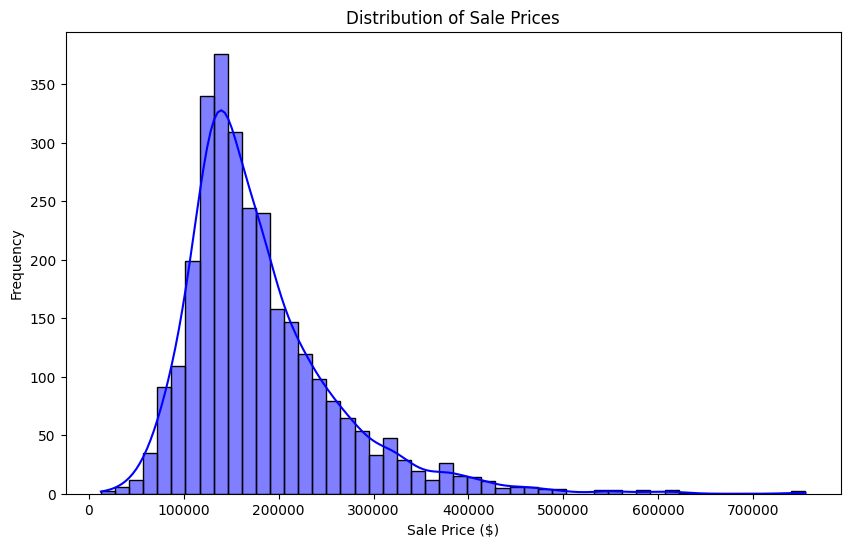

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(house_data['SalePrice'], kde=True, bins=50, color='blue')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.show()

The data is right skewed\
The peak of the tha dataset lies around $150,000

**Identify Columns which has missing values**

In [3]:
# Returns a Series with the count of NaN values for each column
missing_counts = house_data.isnull().sum()

# To see only columns that have missing values:
missing_counts_only = missing_counts[missing_counts > 0]

print(missing_counts_only.head(79))

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


**Separate Features and Labels.**\
**Create separate piplines for numerical and categorical features.**\
**Categorical Transformer fills the missing with none and use one hot encoding.**\
**Numerical Transformer fills with median and scales values.**

In [4]:

X = house_data.drop('SalePrice', axis=1)
y = house_data['SalePrice']

# 1. Automatically separate numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'str']).columns.tolist()

# 1. Define the categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),  # Fill missing with 'None'
    # LabelEncoder is not suitable here – ColumnTransformer sends a 2‑D array,
    # which causes the “takes 2 positional arguments but 3 were given” error.
    # use one‑hot (or ordinal) encoding instead.
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 2. Now define your numeric transformer (if you haven't already)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# 3. Now run your ColumnTransformer cell
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 3. CATCH THE OUTPUT HERE
# .fit_transform() learns the mean/median/categories AND applies the changes
X_processed_array = preprocessor.fit_transform(X)

print("Data successfully transformed!")
print(f"Original shape: {X.shape}")
print(f"New shape: {X_processed_array.shape}")

Data successfully transformed!
Original shape: (2930, 81)
New shape: (2930, 321)


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(house_data)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street Alley Lot Shape Land Contour Utilities Lot Config Land Slope Neighborhood Condition 1 Condition 2 Bldg Type House Style  Overall Qual  Overall Cond  Year Built  Year Remod/Add Roof Style Roof Matl Exterior 1st Exterior 2nd Mas Vnr Type  Mas Vnr Area Exter Qual Exter Cond Foundation Bsmt Qual Bsmt Cond Bsmt Exposure BsmtFin Type 1  BsmtFin SF 1 BsmtFin Type 2  BsmtFin SF 2  Bsmt Unf SF  Total Bsmt SF Heating Heating QC Central Air Electrical  1st Flr SF  2nd Flr SF  Low Qual Fin SF  Gr Liv Area  Bsmt Full Bath  Bsmt Half Bath  Full Bath  Half Bath  Bedroom AbvGr  Kitchen AbvGr Kitchen Qual  TotRms AbvGrd Functional  Fireplaces Fireplace Qu Garage Type  Garage Yr Blt Garage Finish  Garage Cars  Garage Area Garage Qual Garage Cond Paved Drive  Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  Screen Porch  Pool Area Pool QC  Fence Misc Feature  Misc Val  Mo Sold  Yr Sold Sale Type Sale Condition  \
0      

**Fix the sparse Matrix problem by converting it into dense numpy array**

In [6]:
# 1. Decompress the Sparse Matrix into a standard "Dense" NumPy array
# (If it's already dense, this safely ignores it)
if hasattr(X_processed_array, 'toarray'):
    X_dense = X_processed_array.toarray()
else:
    X_dense = X_processed_array

# 2. NOW we can successfully count the missing values
missing_after = np.isnan(X_dense).sum()
print(f"Missing in processed array: {missing_after}")

Missing in processed array: 0


**Rebuild the dataset with the new features**

In [7]:
# 3. Rebuild your clean Pandas DataFrame!
# Get the new expanded column names from the pipeline
new_column_names = preprocessor.get_feature_names_out()

# Create the DataFrame using the decompressed 'X_dense'
clean_ames_df = pd.DataFrame(X_dense, columns=new_column_names)

print(f"Dataset successfully rebuilt with {clean_ames_df.shape[1]} columns!")

Dataset successfully rebuilt with 321 columns!


In [10]:
clean_ames_df.to_csv('clean_ames_housing.csv', index=False)
print("Cleaned dataset saved to 'clean_ames_housing.csv'!")

Cleaned dataset saved to 'clean_ames_housing.csv'!


In [11]:
clean_ames_df['SalePrice'] = y

In [12]:
clean_ames_df.head()

,num__Order,num__PID,num__MS SubClass,num__Lot Frontage,num__Lot Area,num__Overall Qual,num__Overall Cond,num__Year Built,num__Year Remod/Add,num__Mas Vnr Area,num__BsmtFin SF 1,num__BsmtFin SF 2,num__Bsmt Unf SF,num__Total Bsmt SF,num__1st Flr SF,num__2nd Flr SF,num__Low Qual Fin SF,num__Gr Liv Area,num__Bsmt Full Bath,num__Bsmt Half Bath,num__Full Bath,num__Half Bath,num__Bedroom AbvGr,num__Kitchen AbvGr,num__TotRms AbvGrd,num__Fireplaces,num__Garage Yr Blt,num__Garage Cars,num__Garage Area,num__Wood Deck SF,num__Open Porch SF,num__Enclosed Porch,num__3Ssn Porch,num__Screen Porch,num__Pool Area,num__Misc Val,num__Mo Sold,num__Yr Sold,cat__MS Zoning_A (agr),cat__MS Zoning_C (all),cat__MS Zoning_FV,cat__MS Zoning_I (all),cat__MS Zoning_RH,cat__MS Zoning_RL,cat__MS Zoning_RM,cat__Street_Grvl,cat__Street_Pave,cat__Alley_Grvl,cat__Alley_None,cat__Alley_Pave,cat__Lot Shape_IR1,cat__Lot Shape_IR2,cat__Lot Shape_IR3,cat__Lot Shape_Reg,cat__Land Contour_Bnk,cat__Land Contour_HLS,cat__Land Contour_Low,cat__Land Contour_Lvl,cat__Utilities_AllPub,cat__Utilities_NoSeWa,cat__Utilities_NoSewr,cat__Lot Config_Corner,cat__Lot Config_CulDSac,cat__Lot Config_FR2,cat__Lot Config_FR3,cat__Lot Config_Inside,cat__Land Slope_Gtl,cat__Land Slope_Mod,cat__Land Slope_Sev,cat__Neighborhood_Blmngtn,cat__Neighborhood_Blueste,cat__Neighborhood_BrDale,cat__Neighborhood_BrkSide,cat__Neighborhood_ClearCr,cat__Neighborhood_CollgCr,cat__Neighborhood_Crawfor,cat__Neighborhood_Edwards,cat__Neighborhood_Gilbert,cat__Neighborhood_Greens,cat__Neighborhood_GrnHill,cat__Neighborhood_IDOTRR,cat__Neighborhood_Landmrk,cat__Neighborhood_MeadowV,cat__Neighborhood_Mitchel,cat__Neighborhood_NAmes,cat__Neighborhood_NPkVill,cat__Neighborhood_NWAmes,cat__Neighborhood_NoRidge,cat__Neighborhood_NridgHt,cat__Neighborhood_OldTown,cat__Neighborhood_SWISU,cat__Neighborhood_Sawyer,cat__Neighborhood_SawyerW,cat__Neighborhood_Somerst,cat__Neighborhood_StoneBr,cat__Neighborhood_Timber,cat__Neighborhood_Veenker,cat__Condition 1_Artery,cat__Condition 1_Feedr,cat__Condition 1_Norm,cat__Condition 1_PosA,cat__Condition 1_PosN,cat__Condition 1_RRAe,cat__Condition 1_RRAn,cat__Condition 1_RRNe,cat__Condition 1_RRNn,cat__Condition 2_Artery,cat__Condition 2_Feedr,cat__Condition 2_Norm,cat__Condition 2_PosA,cat__Condition 2_PosN,cat__Condition 2_RRAe,cat__Condition 2_RRAn,cat__Condition 2_RRNn,cat__Bldg Type_1Fam,cat__Bldg Type_2fmCon,cat__Bldg Type_Duplex,cat__Bldg Type_Twnhs,cat__Bldg Type_TwnhsE,cat__House Style_1.5Fin,cat__House Style_1.5Unf,cat__House Style_1Story,cat__House Style_2.5Fin,cat__House Style_2.5Unf,cat__House Style_2Story,cat__House Style_SFoyer,cat__House Style_SLvl,cat__Roof Style_Flat,cat__Roof Style_Gable,cat__Roof Style_Gambrel,cat__Roof Style_Hip,cat__Roof Style_Mansard,cat__Roof Style_Shed,cat__Roof Matl_ClyTile,cat__Roof Matl_CompShg,cat__Roof Matl_Membran,cat__Roof Matl_Metal,cat__Roof Matl_Roll,cat__Roof Matl_Tar&Grv,cat__Roof Matl_WdShake,cat__Roof Matl_WdShngl,cat__Exterior 1st_AsbShng,cat__Exterior 1st_AsphShn,cat__Exterior 1st_BrkComm,cat__Exterior 1st_BrkFace,cat__Exterior 1st_CBlock,cat__Exterior 1st_CemntBd,cat__Exterior 1st_HdBoard,cat__Exterior 1st_ImStucc,cat__Exterior 1st_MetalSd,cat__Exterior 1st_Plywood,cat__Exterior 1st_PreCast,cat__Exterior 1st_Stone,cat__Exterior 1st_Stucco,cat__Exterior 1st_VinylSd,cat__Exterior 1st_Wd Sdng,cat__Exterior 1st_WdShing,cat__Exterior 2nd_AsbShng,cat__Exterior 2nd_AsphShn,cat__Exterior 2nd_Brk Cmn,cat__Exterior 2nd_BrkFace,cat__Exterior 2nd_CBlock,cat__Exterior 2nd_CmentBd,cat__Exterior 2nd_HdBoard,cat__Exterior 2nd_ImStucc,cat__Exterior 2nd_MetalSd,cat__Exterior 2nd_Other,cat__Exterior 2nd_Plywood,cat__Exterior 2nd_PreCast,cat__Exterior 2nd_Stone,cat__Exterior 2nd_Stucco,cat__Exterior 2nd_VinylSd,cat__Exterior 2nd_Wd Sdng,cat__Exterior 2nd_Wd Shng,cat__Mas Vnr Type_BrkCmn,cat__Mas Vnr Type_BrkFace,cat__Mas Vnr Type_CBlock,cat__Mas Vnr Type_None,cat__Mas Vnr Type_Stone,cat__Exter Qual_Ex,cat__Exter Qual_Fa,cat__Exter Qual_Gd

In [13]:
clean_ames_df.to_csv('clean_ames_housing.csv', index=False)
print("Cleaned dataset saved to 'clean_ames_housing.csv'!")

Cleaned dataset saved to 'clean_ames_housing.csv'!
